In [2]:
pip install gplearn



SyntaxError: invalid syntax (1939992507.py, line 1)

In [4]:
!pip install gplearn


Defaulting to user installation because normal site-packages is not writeable


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from gplearn.genetic import SymbolicClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load Dataset (Pima Indians Diabetes)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigree", "Age", "Outcome"]
data = pd.read_csv(url, names=columns)

X = data.drop("Outcome", axis=1).values
y = data["Outcome"].values

# Step 2: Preprocessing
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 4: Define Symbolic Classifier (GEP-like)
clf = SymbolicClassifier(
    population_size=1000,
    generations=30,
    tournament_size=20,
    function_set=('add', 'sub', 'mul', 'div', 'sin', 'cos', 'log', 'sqrt'),
    parsimony_coefficient=0.01,   # penalize overly complex formulas
    stopping_criteria=0.95,
    random_state=42,
    verbose=1
)

# Step 5: Train Model
clf.fit(X_train, y_train)

# Step 6: Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 7: Extract Knowledge (Discovered Rule)
print("\nDiscovered Rule (Knowledge):\n")
print(clf._program)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    10.12          1.07966        3         0.550862              N/A      8.29s
Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.62      0.71       151
           1       0.51      0.75      0.61        80

    accuracy                           0.67       231
   macro avg       0.67      0.69      0.66       231
weighted avg       0.72      0.67      0.67       231


Discovered Rule (Knowledge):

add(X5, X1)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    23.38          2506.91        3         0.161121          0.19096      3.69s
   1     6.69          1.47086        2         0.142573         0.195852      2.68s
   2     3.74           2.2262        2         0.140121         0.217922      2.33s
   3     2.30         0.935632        2         0.136702          0.24869      2.18s
   4     2.25         0.719983        2         0.135645         0.258202      2.02s
   5     2.38          3.05548        2         0.140917         0.210759      1.92s
   6     2.37          1.57993        2         0.140462         0.214854      1.76s
   7     2.39          2.42616        2         0.140399         0.215421      1.62s
   8     2.30          1.10705        2         0.139022         0.227808  

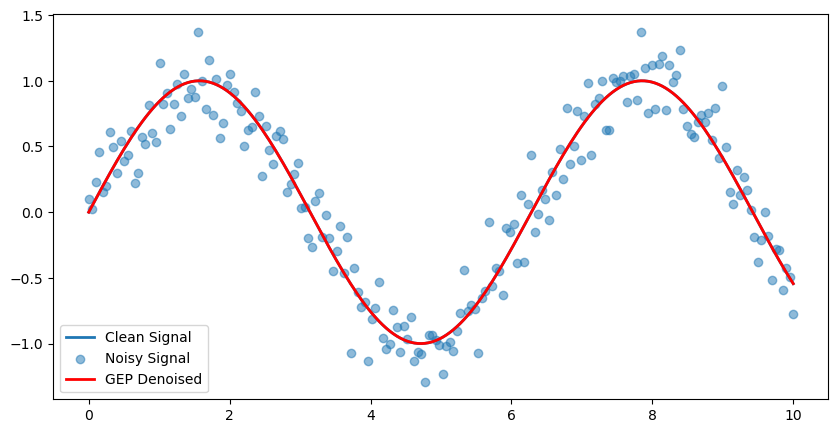

Best evolved function:
 sin(X0)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gplearn.genetic import SymbolicRegressor
from gplearn.functions import make_function

# Step 1: Generate synthetic signal
np.random.seed(42)
x = np.linspace(0, 10, 200).reshape(-1, 1)
y_clean = np.sin(x).ravel()
y_noisy = y_clean + np.random.normal(0, 0.2, size=y_clean.shape)

# Step 2: Define symbolic regressor (like GEP)
est_gp = SymbolicRegressor(
    population_size=500,
    generations=20,
    tournament_size=20,
    stopping_criteria=0.01,
    function_set=('add', 'sub', 'mul', 'div', 'sin', 'cos'),
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    parsimony_coefficient=0.01,
    random_state=42
)

# Step 3: Train the GP (evolves a formula)
est_gp.fit(x, y_noisy)

# Step 4: Predict on noisy signal
y_pred = est_gp.predict(x)

# Step 5: Plot results
plt.figure(figsize=(10, 5))
plt.plot(x, y_clean, label="Clean Signal", linewidth=2)
plt.scatter(x, y_noisy, label="Noisy Signal", alpha=0.5)
plt.plot(x, y_pred, label="GEP Denoised", color='red', linewidth=2)
plt.legend()
plt.show()

print("Best evolved function:\n", est_gp._program)
